In [3]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis s3fs fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 1.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 790.9 kB/s eta 0:00:0000:0100:01


In [1]:
%pip install xarray fsspec s3fs netCDF4 h5netcdf scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 4.3 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

In [4]:
import datetime as dt
import xarray as xr
import fsspec
import s3fs
import os.path
import matplotlib.pyplot as plt

In [ ]:
fs = s3fs.S3FileSystem(anon=True)

files = fs.ls("s3://noaa-goes16/ABI-L2-CMIPC/2024/200/18/")
files[:5]

['noaa-goes16/ABI-L2-CMIPC/2024/200/18/OR_ABI-L2-CMIPC-M6C01_G16_s20242001801181_e20242001803554_c20242001804017.nc',
 'noaa-goes16/ABI-L2-CMIPC/2024/200/18/OR_ABI-L2-CMIPC-M6C01_G16_s20242001806181_e20242001808555_c20242001809025.nc',
 'noaa-goes16/ABI-L2-CMIPC/2024/200/18/OR_ABI-L2-CMIPC-M6C01_G16_s20242001811181_e20242001813554_c20242001814028.nc',
 'noaa-goes16/ABI-L2-CMIPC/2024/200/18/OR_ABI-L2-CMIPC-M6C01_G16_s20242001816181_e20242001818554_c20242001819019.nc',
 'noaa-goes16/ABI-L2-CMIPC/2024/200/18/OR_ABI-L2-CMIPC-M6C01_G16_s20242001821181_e20242001823554_c20242001824024.nc']

In [3]:
import xarray as xr
import matplotlib.pyplot as plt

file = "OR_ABI-L2-CMIPC-M6C13_G19_s20261251801177_e20261251803562_c20261251804024.nc"

ds = xr.open_dataset(file)
ds

<xarray.Dataset> Size: 30MB
Dimensions:                                           (y: 1500, x: 2500,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       band: 1)
Coordinates:
  * y                                                 (y) float32 6kB 0.1282 ...
  * x                                                 (x) float32 10kB -0.101...
    band_wavelength                                   (band) float32 4B ...
    band_id                                           (band) int32 4B ...
    t                                                 datetime64[ns] 8B ...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
Dimensions without coordinates: number_of_time_bounds, number_of_image_bounds,
                                band
Data variables: (12/35)
    CMI                                               (y, x) float32 15MB ...
    DQF                                               (y, x) float32 15MB ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                            int32 4B ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    ...                                                ...
    focal_plane_temperature_threshold_exceeded_count  float64 8B ...
    maximum_focal_plane_temperature                   float32 4B ...
    focal_plane_temperature_threshold_increasing      float32 4B ...
    focal_plane_temperature_threshold_decreasing      float32 4B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/29)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    ...                        ...
    cdm_data_type:             Image
    time_coverage_start:       2026-05-05T18:01:17.7Z
    time_coverage_end:         2026-05-05T18:03:56.2Z
    timeline_id:               ABI Mode 6
    production_data_source:    Realtime
    id:                        b5144912-88ea-47e9-b74f-f2ec0b3795f0

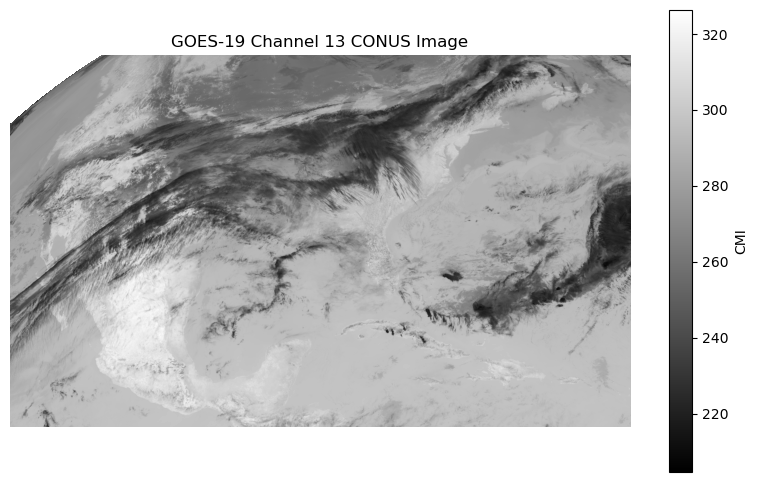

In [4]:
data = ds["CMI"]

plt.figure(figsize=(10, 6))
plt.imshow(data, cmap="gray")
plt.colorbar(label="CMI")
plt.title("GOES-19 Channel 13 CONUS Image")
plt.axis("off")
plt.show()